<a href="https://colab.research.google.com/github/beyzahiz/Sentiment-Analysis-NLP/blob/main/05_bert_sentiment_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install transformers
import pandas as pd
import torch
from sklearn.model_selection import train_test_split

from transformers import(
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("IMDB Dataset.csv")

df['sentiment'] = df['sentiment'].map({
    "positive":1,
    "negative":0
})

In [3]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['review'],
    df['sentiment'],
    test_size=0.2,
    random_state=42
)

In [4]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [5]:
train_encodings = tokenizer(
    train_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=256
)

test_encodings = tokenizer(
    test_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=256
)

In [6]:
class IMDbDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels.iloc[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [7]:
train_dataset = IMDbDataset(train_encodings, train_labels)
test_dataset = IMDbDataset(test_encodings, test_labels)

In [8]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [9]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,  #bellek yetsin diye sekizerli grupluyoruz veriyi
    per_device_eval_batch_size=8,
    num_train_epochs=2
)

In [10]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

In [11]:
trainer.train()

Step,Training Loss
500,0.390515
1000,0.315452
1500,0.298993
2000,0.282371
2500,0.304952
3000,0.274498
3500,0.261993
4000,0.266906
4500,0.277592
5000,0.254543


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=10000, training_loss=0.22927484970092774, metrics={'train_runtime': 4767.4563, 'train_samples_per_second': 16.78, 'train_steps_per_second': 2.098, 'total_flos': 1.05244422144e+16, 'train_loss': 0.22927484970092774, 'epoch': 2.0})

In [12]:
trainer.evaluate()

{'eval_loss': 0.3122093379497528,
 'eval_runtime': 170.1275,
 'eval_samples_per_second': 58.779,
 'eval_steps_per_second': 7.347,
 'epoch': 2.0}

In [13]:
from sklearn.metrics import accuracy_score
predictions = trainer.predict(test_dataset)
preds = predictions.predictions.argmax(axis=1)
accuracy = accuracy_score(test_labels, preds)
print("BERT Accuracy:", accuracy)

BERT Accuracy: 0.9255


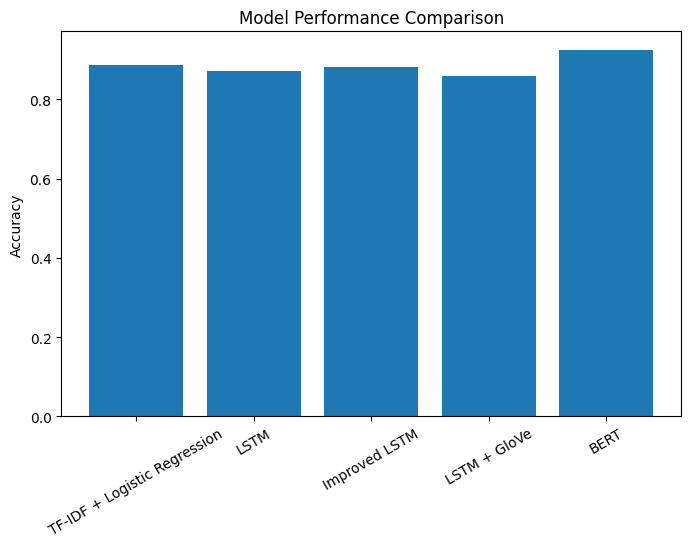

In [14]:
models = [
    "TF-IDF + Logistic Regression",
    "LSTM",
    "Improved LSTM",
    "LSTM + GloVe",
    "BERT"
]

scores = [
    0.887,
    0.872,
    0.881,
    0.86,
    accuracy
]

plt.figure(figsize=(8,5))
plt.bar(models, scores)
plt.xticks(rotation=30)
plt.ylabel("Accuracy")
plt.title("Model Performance Comparison")
plt.show()

In [15]:
def predict_sentiment(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    )

    # Move inputs to the same device as the model
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    outputs = model(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=1)
    pred = torch.argmax(probs).item()
    return "Positive" if pred == 1 else "Negative"

predict_sentiment("This movie was absolutely amazing!")


'Positive'

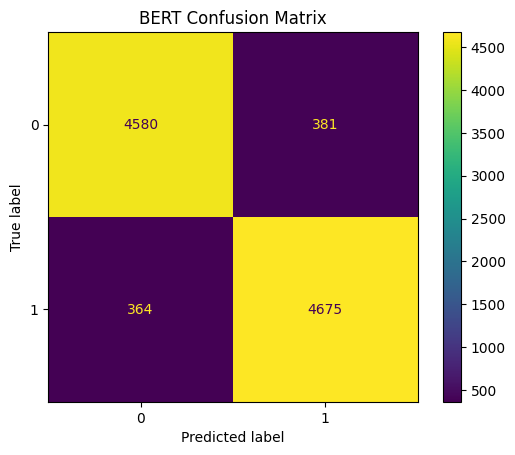

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(test_labels, preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.title("BERT Confusion Matrix")
plt.show()

In [17]:
from sklearn.metrics import classification_report

print(classification_report(test_labels, preds))

              precision    recall  f1-score   support

           0       0.93      0.92      0.92      4961
           1       0.92      0.93      0.93      5039

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



In [18]:
model.save_pretrained("sentiment_model")
tokenizer.save_pretrained("sentiment_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('sentiment_model/tokenizer_config.json', 'sentiment_model/tokenizer.json')